# Exploratory Data Analysis - Titanic

## Imports and functions

In [1]:
# Imports
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def plot_distribution(df, column, bins=30):
    """
    Plot the distribution of a numerical feature using a histogram and KDE.
    """

    data = df[column]

    plt.figure(figsize=(8,5))

    sns.histplot(data, bins=bins, kde=True)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.show()


def plot_survival_rate(df, column):
    """
    Plot survival counts grouped by a categorical feature.
    """

    plt.figure(figsize=(8,5))

    sns.countplot(x=column, hue="Survived", data=df)

    plt.title(f"Survival by {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.legend(title="Survived")

    plt.show()

## Dataset overview

In [3]:
# Load
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


The dataset contains 891 passenger records and 11 features describing passenger characteristics such as age, sex, ticket class and fare.\
The target variable is 'Survived'.

In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [8]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Test dataset structure looks similar to train dataset.\
There's a missing value in the Fare column.

## Missing values

In [9]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

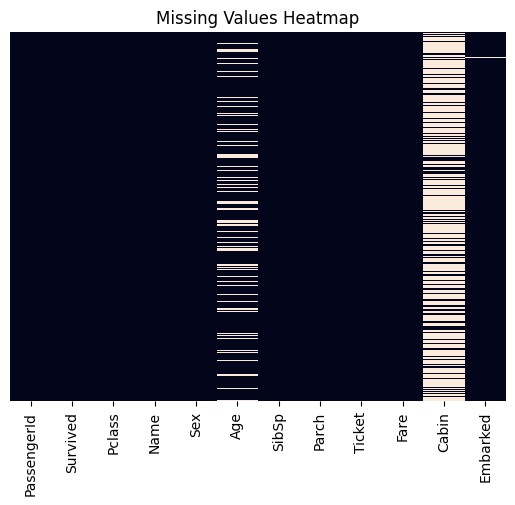

In [10]:
#plt.figure(figsize=(12,8))
plt.title('Missing Values Heatmap')
sns.heatmap(train.isnull(), cbar=False, yticklabels=False)
plt.show()

- Age contains several missing values.
- Cabin has a high percentage of missing data and may require feature engineering or removal.
- Embarked has only a few missing entries.

## Distribution plots

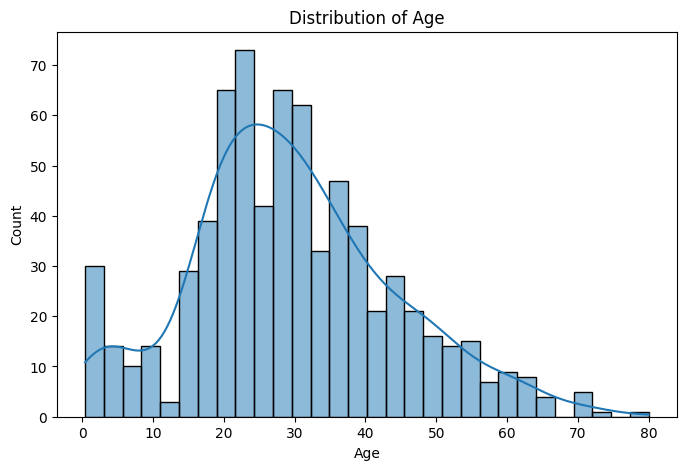

In [11]:
plot_distribution(train, 'Age')

Age distribution is right-skewed with most passengers between 20 and 40 years old.

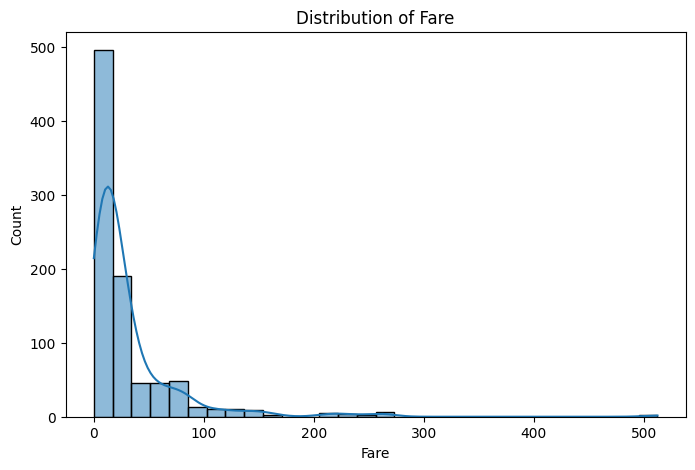

In [12]:
plot_distribution(train, 'Fare')

Fare is highly skewed due to a few passengers paying extremely high ticket prices.

## Survival analysis

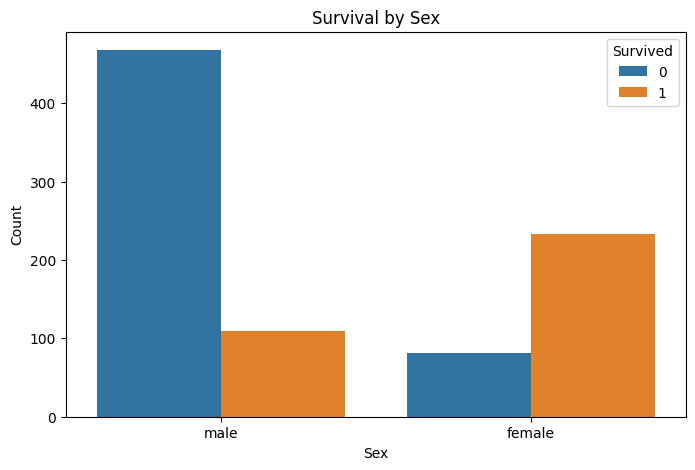

In [13]:
plot_survival_rate(train, "Sex")

Female passengers have a significantly higher survival probability compared to males.

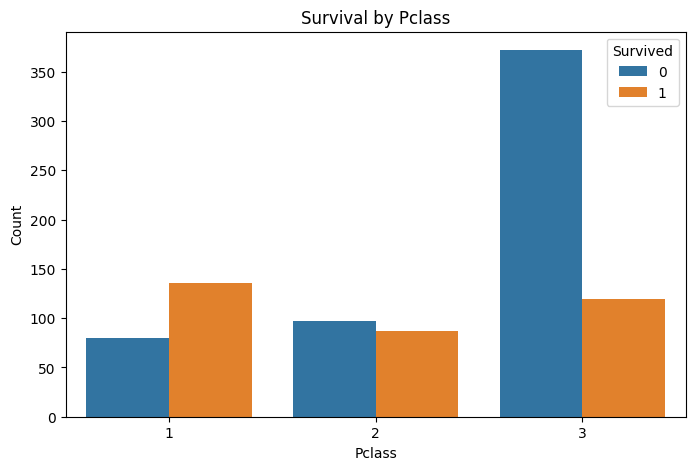

In [14]:
plot_survival_rate(train, 'Pclass')

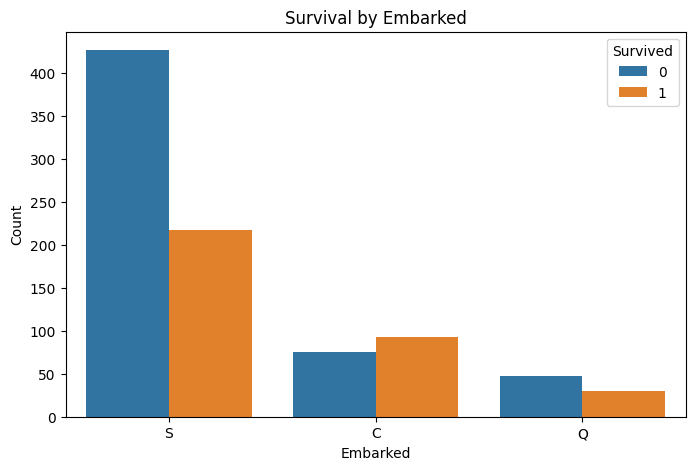

In [15]:
plot_survival_rate(train, 'Embarked')

Passengers from higher classes had a greater chance of survival.

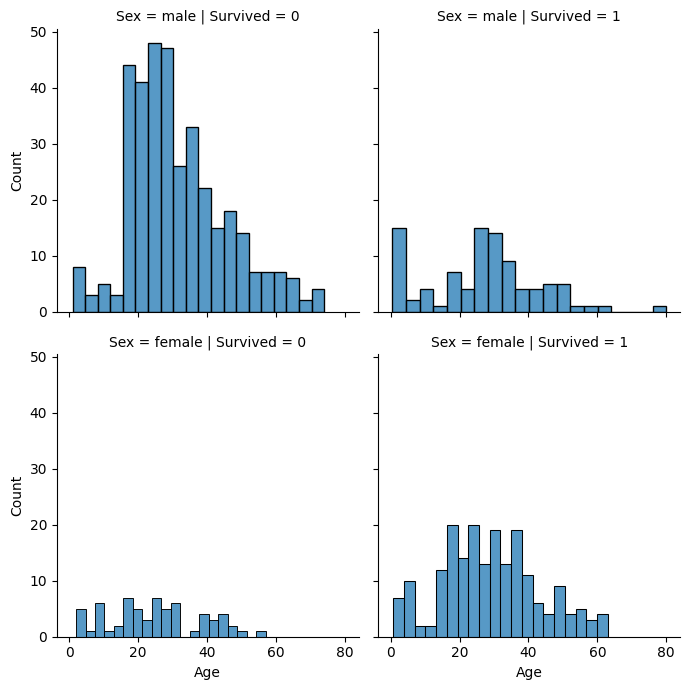

In [16]:
g = sns.FacetGrid(train, col="Survived", row="Sex", height=3.5)

g.map(sns.histplot, "Age", bins=20)

g.set_axis_labels("Age", "Count")

plt.show()

Women show a significantly higher survival rate than men.\
Children also appear to have a higher survival probability, suggesting a "women and children first" evacuation pattern.

## Correlations

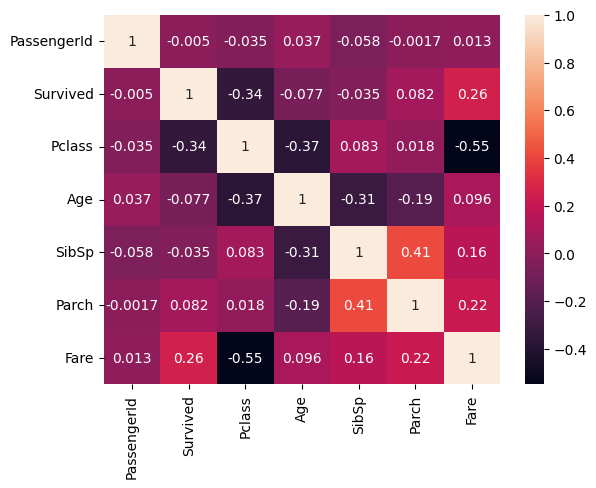

In [ ]:
corr = train.corr(numeric_only=True)

sns.heatmap(corr, annot=True, linewidths=0.5)
plt.show()

Fare shows moderate correlation with Pclass.\
Age has weak correlation with survival.

## Insights

- Female passengers had significantly higher survival rates.
- Higher ticket classes were associated with higher survival probability.
- Fare distribution is highly skewed.
- Cabin contains many missing values but deck information might be useful.
- Family size may influence survival chances.